# **Customer Churn**

### **Assignment_03**
### **Submitted By**

- Awais Manzoor (SP24-BBD-026)  
- Fawad Saqib (SP24-BBD-047)  
- M. Haisam (SP24-BBD-096)

## **Problem Statement**
Customer churn is a major concern for banks as it directly reduces profitability and long-term growth. This study applies a binary choice econometric approach (Logit model) to identify the key factors that influence whether a customer leaves the bank or remains active. The objective is to estimate a statistical model and use it for prediction and business decision-making.

###  **Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_curve, roc_auc_score

import statsmodels.api as sm

## **Load Dataset**

In [2]:
df = pd.read_csv('C:/Users/Awais/Desktop/Eco_Ass_03/Churn_Modelling.csv')
df.sample(5)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
8772,8773,15592123,Buccho,768,France,Male,30,6,0.00,2,1,1,199454.37,0
2383,2384,15642468,Clark,697,France,Male,42,9,132739.26,2,0,0,174667.65,0
2924,2925,15792818,Perry,499,Germany,Female,29,6,148051.52,1,1,0,118623.94,0
9766,9767,15795511,Vasiliev,800,Germany,Male,39,4,95252.72,1,1,0,13906.34,0
8114,8115,15607269,Costa,492,Germany,Female,49,2,151249.45,2,1,1,167237.94,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [4]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


### **Check_Missing_Values**

In [5]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

### **Drop Irrelevant Columns**

In [6]:
df.drop(['RowNumber','CustomerId','Surname'], axis=1, inplace=True)

###  **EDA and Preprocessing**

#### **Target Variable Distribution**

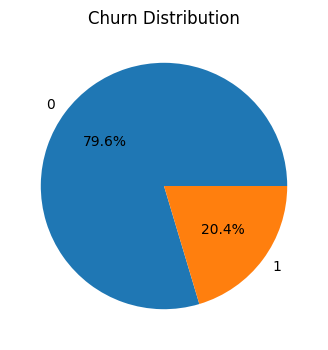

In [8]:
plt.figure(figsize=(4,4))
df['Exited'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title("Churn Distribution")
plt.ylabel("")
plt.show()

#### **Numerical Features**

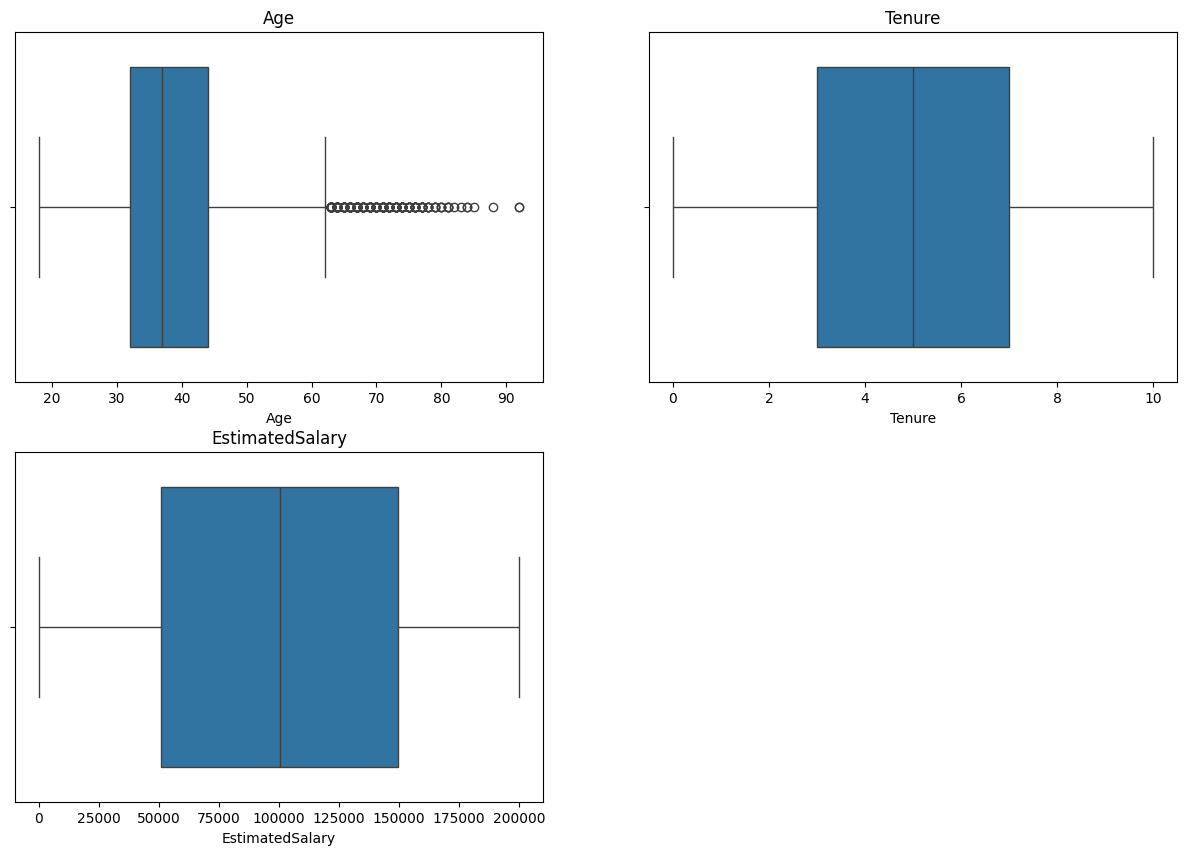

In [9]:
plt.figure(figsize=(15,10))
for i, col in enumerate(['Age','Tenure','EstimatedSalary']):
    plt.subplot(2,2,i+1)
    sns.boxplot(x=df[col])
    plt.title(col)
plt.show()

In [10]:
# Outlier treatment using IQR method
Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)
IQR = Q3 - Q1


In [11]:

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df['Age'] = np.clip(df['Age'], lower_bound, upper_bound)
print(f"Age range after fixing: {df['Age'].min()} to {df['Age'].max()}")

Age range after fixing: 18 to 62


#### **Categorical Features**

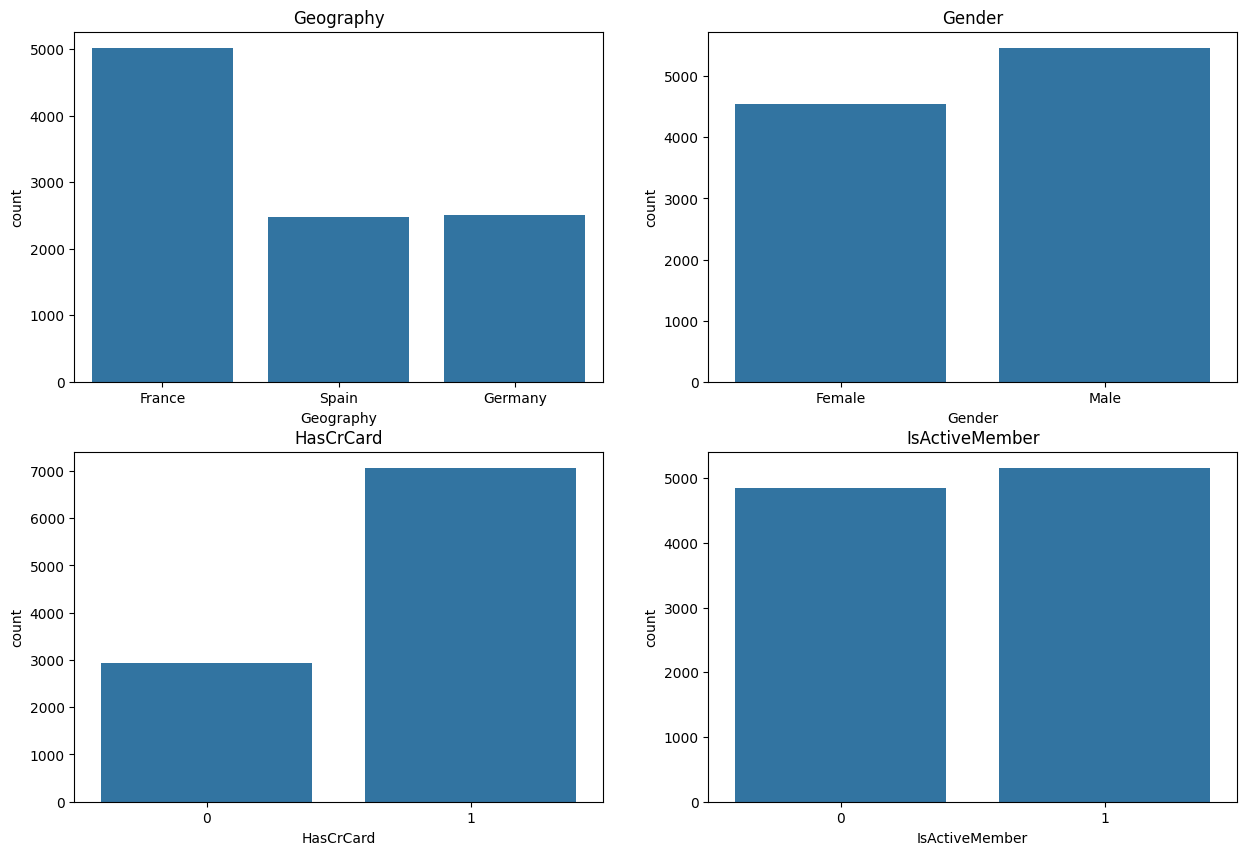

In [12]:
plt.figure(figsize=(15,10))
for i, col in enumerate(['Geography','Gender','HasCrCard','IsActiveMember']):
    plt.subplot(2,2,i+1)
    sns.countplot(x=df[col])
    plt.title(col)
plt.show()

# Exploratory Data Analysis

- The dataset is slightly imbalanced (majority non-churn customers).
- Age shows potential outliers which are treated using IQR method.
- Most customers are from France.
- Gender distribution is balanced.
- Active members are slightly higher in number.

#### **Encoding**

In [13]:
df = pd.get_dummies(df, columns=['Geography','Gender'], drop_first=True)
df.head()


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False


- Converted categorical data into numbers for model training.

#### **Split Data**

In [14]:
X = df.drop('Exited', axis=1)
y = df['Exited']

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### **Scaling**

In [20]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

- Scaled data so all features have equal importance.

In [23]:
X_train = pd.DataFrame(X_train).reset_index(drop=True)
X_test = pd.DataFrame(X_test).reset_index(drop=True)

y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

In [24]:
X_train.columns = X.columns
X_test.columns = X.columns

### **Model Specification & Estimation**

In [25]:
X_train_sm = sm.add_constant(X_train)
logit_model = sm.Logit(y_train, X_train_sm).fit()
print(logit_model.summary())

Optimization terminated successfully.
         Current function value: 0.422566
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                 Exited   No. Observations:                 8000
Model:                          Logit   Df Residuals:                     7988
Method:                           MLE   Df Model:                           11
Date:                Sun, 26 Apr 2026   Pseudo R-squ.:                  0.1681
Time:                        02:52:08   Log-Likelihood:                -3380.5
converged:                       True   LL-Null:                       -4063.5
Covariance Type:            nonrobust   LLR p-value:                2.779e-286
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -1.6786      0.035    -47.501      0.000      -1.748      -1.609
CreditSc

# Model Interpretation

- Age: positive effect → older customers slightly more likely to churn
- Balance: strong positive effect → high-balance customers are more likely to leave
- IsActiveMember: negative and significant → active customers are less likely to churn
- Geography (Germany): positive effect → higher churn compared to France

Variables with p < 0.05 are statistically significant and strongly affect churn behavior.

###  **Model Evaluation**

- **Predict Probabilities on Test Set**

In [27]:
X_test_sm = sm.add_constant(X_test)
y_prob = logit_model.predict(X_test_sm)

# Default prediction (threshold = 0.5)
y_pred = (y_prob >= 0.5).astype(int)

- **Confusion Matrix**

In [28]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[1541   66]
 [ 300   93]]


- **Metrics**

In [29]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Accuracy: 0.817
Precision: 0.5849056603773585
Recall: 0.2366412213740458
F1-score: 0.33695652173913043


### **ROC Curve and AUC**

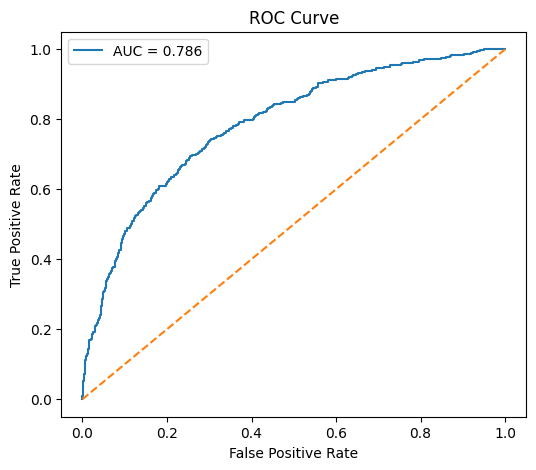

AUC Score: 0.7862215403031584


In [30]:
from sklearn.metrics import roc_curve, auc
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

print("AUC Score:", roc_auc)

## **Optimal Threshold Selection**

In [31]:
import numpy as np

youden_index = tpr - fpr
best_index = np.argmax(youden_index)

best_threshold = thresholds[best_index]
print("Best Threshold:", best_threshold)

Best Threshold: 0.22016748163802596


In [32]:
y_pred_best = (y_prob >= best_threshold).astype(int)

- **Evaluation with Best Threshold**

In [33]:
cm_best = confusion_matrix(y_test, y_pred_best)

accuracy_best = accuracy_score(y_test, y_pred_best)
precision_best = precision_score(y_test, y_pred_best)
recall_best = recall_score(y_test, y_pred_best)
f1_best = f1_score(y_test, y_pred_best)

print(cm_best)
print("Accuracy:", accuracy_best)
print("Precision:", precision_best)
print("Recall:", recall_best)
print("F1-score:", f1_best)

[[1197  410]
 [ 120  273]]
Accuracy: 0.735
Precision: 0.39970717423133234
Recall: 0.6946564885496184
F1-score: 0.5074349442379182


## **Insights**
The optimized threshold (0.22) improves recall significantly compared to the default threshold (0.5). Therefore, it is more suitable for churn prediction as missing a churner is more costly than a false alarm.

## **Business Interpretation**

- **Odds Ratios**

In [68]:
odds_ratios = np.exp(logit_model.params)
print(odds_ratios)

const    0.186628
x1       0.938181
x2       2.349727
x3       0.958697
x4       1.170881
x5       0.943166
x6       0.992033
x7       0.582609
x8       1.016058
x9       1.403562
x10      1.036582
x11      0.765768
dtype: float64


# **Business Interpretation (Odds Ratios)**

- Age (0.94): Older customers are 6% less likely to churn
- Balance (2.34): High-balance customers are 134% more likely to churn
- Number of Products (0.58): Reduces churn by 42%
- IsActiveMember (0.76): Active customers are 24% less likely to churn
- Germany (1.40): Customers from Germany are 40% more likely to churn

# **Key Insight**

Churn is mainly driven by financial behavior, engagement level, and geography.

# **Recommendations**

- Focus on high-balance customers for retention
- Improve customer engagement programs
- Promote product bundling
- Address high churn regions (Germany)